In [86]:
%load_ext autoreload

%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
import numpy as np
import pickle
from typing import Dict, List, Tuple, Union, Optional, Any
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, SVG
from rdkit.Chem import rdFingerprintGenerator
import shap


In [56]:
def _extract_shap_values(shap_values, compound_index: int) -> np.ndarray:
    """SHAP値を適切な形式で抽出"""
    if hasattr(shap_values, 'values'):
        values = shap_values.values
    else:
        values = shap_values
    
    if isinstance(values, list):
        return np.array(values[1][compound_index]).flatten()
    elif values.ndim == 3:
        return values[compound_index, :, 1].flatten()
    else:
        return values[compound_index].flatten()

def _calculate_color(contribution: float, max_intensity: float = 1.0) -> Tuple[float, float, float]:
    """貢献度から色を計算"""
    if contribution == 0:
        return (0.8, 0.8, 0.8)  # 灰色
    
    intensity = min(max_intensity, abs(contribution))
    if contribution > 0:
        return (1, 1-intensity, 1-intensity)  # 赤系
    else:
        return (1-intensity, 1-intensity, 1)  # 青系

def _calculate_auto_scale_factor(shap_array: np.ndarray, target_intensity: float = 1.0) -> float:
    
    shap_nonzero = shap_array[shap_array != 0]
    if len(shap_nonzero) == 0:
        return 1.0  
    max_abs_value = np.abs(shap_nonzero).max()
    if max_abs_value == 0:
        return 1.0
    
    return target_intensity / max_abs_value

def visualize_shap_on_molecule(
    compound_name: str,
    df, 
    shap_values: Union[np.ndarray, List], 
    radius,
    nBits,
    compound_column,
    mol_column,
    output: str,
    size: Tuple[int, int] = (300, 300),
) -> str:
    """
    化合物名を指定してSHAP値をECFPベースで分子構造上に可視化
    
    Parameters:
    - scale_factor: 手動スケールファクター（Noneで絶対値最大値ベースの自動計算）
    """
    
    # 化合物データを取得
    matching_rows = df[df[compound_column] == compound_name]
    if matching_rows.empty:
        raise ValueError(f"化合物 '{compound_name}' が見つかりません")
    
    compound_index = matching_rows.index[0]
    mol = matching_rows.iloc[0][mol_column]
    
    if mol is None:
        raise ValueError(f"化合物 '{compound_name}' の分子オブジェクトがNull")
    
    
    shap_array = _extract_shap_values(shap_values, compound_index)
    if len(shap_array) > nBits:
        shap_array = shap_array[:nBits]
    
    scale_factor = _calculate_auto_scale_factor(shap_array)
    
    bit_info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits, bitInfo=bit_info)
    
    # 各原子への貢献度を計算
    atom_contributions = np.zeros(mol.GetNumAtoms())
    
    for bit_idx, shap_value in enumerate(shap_array):
        if bit_idx not in bit_info or shap_value == 0:
            continue
            
        contribution_per_occurrence = shap_value / len(bit_info[bit_idx])
        
        for atom_idx, bit_radius in bit_info[bit_idx]:
            if bit_radius == 0:
                atom_contributions[atom_idx] += contribution_per_occurrence
            else:
                # 原子環境の場合、環境内の原子に分散
                amap = {}
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, bit_radius, atom_idx)
                Chem.PathToSubmol(mol, env, atomMap=amap)
                
                if len(amap) > 0:
                    contribution_per_atom = contribution_per_occurrence / len(amap)
                    for atom in amap:
                        atom_contributions[atom] += contribution_per_atom
    

    atom_contributions *= scale_factor
    atom_colors = {i: _calculate_color(contrib) for i, contrib in enumerate(atom_contributions)}
    
    bond_colors = {}
    for bond in mol.GetBonds():
        avg_contrib = (atom_contributions[bond.GetBeginAtomIdx()] + 
                      atom_contributions[bond.GetEndAtomIdx()]) / 2
        bond_colors[bond.GetIdx()] = _calculate_color(avg_contrib)
    
    # 分子を描画
    view = rdMolDraw2D.MolDraw2DSVG(size[0], size[1])
    view.drawOptions().addAtomIndices = False
    view.drawOptions().useBWAtomPalette()
    
    rdDepictor.Compute2DCoords(mol)
    prepared_mol = rdMolDraw2D.PrepareMolForDrawing(mol)
    
    view.DrawMolecule(
        prepared_mol,
        highlightAtoms=list(range(mol.GetNumAtoms())),
        highlightAtomColors=atom_colors,
        highlightBonds=list(range(mol.GetNumBonds())),
        highlightBondColors=bond_colors
    )
    
    view.FinishDrawing()
    svg = view.GetDrawingText()
    
    # display(SVG(svg))
    with open(output, 'w', encoding='utf-8') as f:
        f.write(svg)

    return svg

In [81]:
with open("result_SHAP/fpdoc2vecvalue/antioxidant_xor500000.pkl", "rb") as f:
    value = pickle.load(f)
value.base_values

array([0.02369393, 0.02742617, 0.02557089, ..., 0.02580915, 0.02593776,
       0.02066374])

In [73]:
with open("result_SHAP/fpdoc2vecvalue/antioxidant_xor500000.pkl", "rb") as f:
    value = pickle.load(f)
value.base_values.shape

(3926,)

In [71]:
with open("result_SHAP/ECFPvalue1/antioxidant_ecfp.pkl", "rb") as f:
    value = pickle.load(f)
value

.values =
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

.base_values =
array([-1.51007234, -1.51007234, -1.51007234, ..., -1.51007234,
       -1.51007234, -1.51007234])

.data =
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [4]:
from rdkit.Chem import AllChem
with open("data/10genre_all.pkl", "rb") as f:
    df = pickle.load(f)
with open("result_SHAP/antioxidant_xor500000.pkl", "rb") as f:
    value = pickle.load(f)
df["NAME"] = [i[0] for i in list(df["compounds"])]

In [58]:
# fp doc2vec

with open("result_SHAP/antibacterial_agent_xor500000.pkl", "rb") as f:
    value = pickle.load(f)
a=visualize_shap_on_molecule("nitrofurazone",
    df, 
    value, 
    radius = 3,
    nBits = 4096,
    compound_column = 'NAME',
    mol_column = 'ROMol',
    output = "result_SHAP/nitrofurazone_fp_doc2vec.svg",
    size = (300, 300)
)

[13:27:38] DEPRECATION WARNING: please use MorganGenerator


[15:18:41] DEPRECATION WARNING: please use MorganGenerator


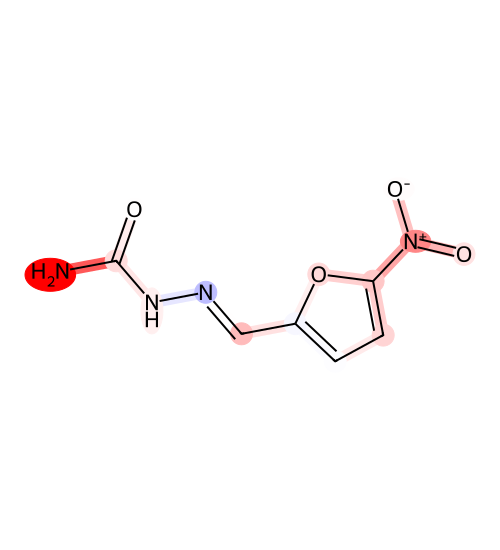

"<?xml version='1.0' encoding='iso-8859-1'?>\n<svg version='1.1' baseProfile='full'\n              xmlns='http://www.w3.org/2000/svg'\n                      xmlns:rdkit='http://www.rdkit.org/xml'\n                      xmlns:xlink='http://www.w3.org/1999/xlink'\n                  xml:space='preserve'\nwidth='500px' height='550px' viewBox='0 0 500 550'>\n<!-- END OF HEADER -->\n<rect style='opacity:1.0;fill:#FFFFFF;stroke:none' width='500.0' height='550.0' x='0.0' y='0.0'> </rect>\n<path class='bond-0 atom-0 atom-1' d='M 111.8,255.7 L 116.2,260.8 L 114.0,267.2 L 63.5,276.7 L 61.3,265.2 Z' style='fill:#FF5858;fill-rule:evenodd;fill-opacity:1;stroke:#FF5858;stroke-width:0.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-miterlimit:10;stroke-opacity:1;' />\n<path class='bond-1 atom-1 atom-2' d='M 128.9,207.2 L 139.9,211.1 L 122.9,259.6 L 116.2,260.8 L 111.8,255.7 Z' style='fill:#FFEDED;fill-rule:evenodd;fill-opacity:1;stroke:#FFEDED;stroke-width:0.0px;stroke-linecap:butt;stroke-linejoi

In [129]:
# ecfp

with open("result_SHAP/antibacterial_agent_ecfp.pkl", "rb") as f:
    value = pickle.load(f)
visualize_shap_on_molecule("nitrofurazone",
    df, 
    value, 
    radius = 3,
    nBits = 4096,
    compound_column = 'NAME',
    mol_column = 'ROMol',
    output = "result_SHAP/nitrofurazone_ECFP.svg",
    size = (500, 550)
)

[15:18:53] DEPRECATION WARNING: please use MorganGenerator


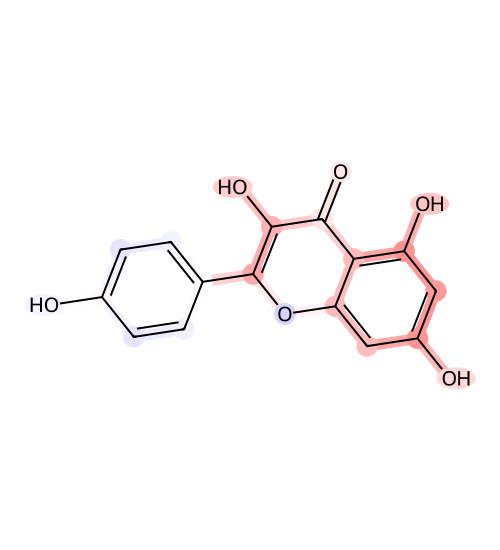

"<?xml version='1.0' encoding='iso-8859-1'?>\n<svg version='1.1' baseProfile='full'\n              xmlns='http://www.w3.org/2000/svg'\n                      xmlns:rdkit='http://www.rdkit.org/xml'\n                      xmlns:xlink='http://www.w3.org/1999/xlink'\n                  xml:space='preserve'\nwidth='500px' height='550px' viewBox='0 0 500 550'>\n<!-- END OF HEADER -->\n<rect style='opacity:1.0;fill:#FFFFFF;stroke:none' width='500.0' height='550.0' x='0.0' y='0.0'> </rect>\n<path class='bond-0 atom-0 atom-1' d='M 335.5,169.6 L 345.7,173.5 L 328.2,218.1 L 322.0,219.0 L 318.1,214.1 Z' style='fill:#FFE6E6;fill-rule:evenodd;fill-opacity:1;stroke:#FFE6E6;stroke-width:0.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-miterlimit:10;stroke-opacity:1;' />\n<path class='bond-1 atom-1 atom-2' d='M 318.1,214.1 L 322.0,219.0 L 319.7,224.9 L 275.6,231.6 L 271.7,226.7 L 273.9,220.8 Z' style='fill:#FFCBCB;fill-rule:evenodd;fill-opacity:1;stroke:#FFCBCB;stroke-width:0.0px;stroke-linecap:but

In [130]:
# fp doc2vec

with open("result_SHAP/antioxidant_xor500000.pkl", "rb") as f:
    value = pickle.load(f)
visualize_shap_on_molecule("kaempferol",
    df, 
    value, 
    radius = 3,
    nBits = 4096,
    compound_column = 'NAME',
    mol_column = 'ROMol',
    output = "result_SHAP/kaempferol_fpdoc2vec.svg",
    size = (500, 550)
)

[15:19:27] DEPRECATION WARNING: please use MorganGenerator


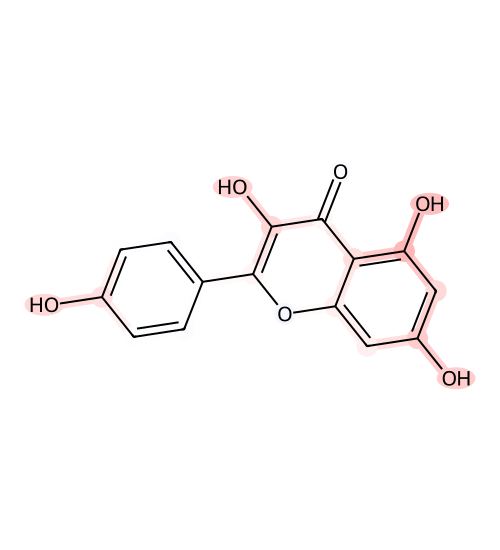

"<?xml version='1.0' encoding='iso-8859-1'?>\n<svg version='1.1' baseProfile='full'\n              xmlns='http://www.w3.org/2000/svg'\n                      xmlns:rdkit='http://www.rdkit.org/xml'\n                      xmlns:xlink='http://www.w3.org/1999/xlink'\n                  xml:space='preserve'\nwidth='500px' height='550px' viewBox='0 0 500 550'>\n<!-- END OF HEADER -->\n<rect style='opacity:1.0;fill:#FFFFFF;stroke:none' width='500.0' height='550.0' x='0.0' y='0.0'> </rect>\n<path class='bond-0 atom-0 atom-1' d='M 335.5,169.6 L 345.7,173.5 L 328.2,218.1 L 322.0,219.0 L 318.1,214.1 Z' style='fill:#FFFDFD;fill-rule:evenodd;fill-opacity:1;stroke:#FFFDFD;stroke-width:0.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-miterlimit:10;stroke-opacity:1;' />\n<path class='bond-1 atom-1 atom-2' d='M 318.1,214.1 L 322.0,219.0 L 319.7,224.9 L 275.6,231.6 L 271.7,226.7 L 273.9,220.8 Z' style='fill:#FFE7E7;fill-rule:evenodd;fill-opacity:1;stroke:#FFE7E7;stroke-width:0.0px;stroke-linecap:but

In [132]:
# ecfp

with open("result_SHAP/antioxidant_ecfp.pkl", "rb") as f:
    value = pickle.load(f)
visualize_shap_on_molecule("kaempferol",
    df, 
    value, 
    radius = 3,
    nBits = 4096,
    compound_column = 'NAME',
    mol_column = 'ROMol',
    output = "result_SHAP/kaempferol_ECFP.svg",
    size = (500, 550)
)

[15:34:37] DEPRECATION WARNING: please use MorganGenerator


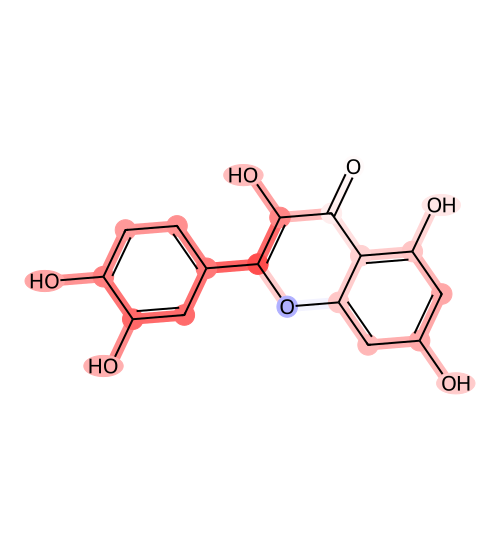

"<?xml version='1.0' encoding='iso-8859-1'?>\n<svg version='1.1' baseProfile='full'\n              xmlns='http://www.w3.org/2000/svg'\n                      xmlns:rdkit='http://www.rdkit.org/xml'\n                      xmlns:xlink='http://www.w3.org/1999/xlink'\n                  xml:space='preserve'\nwidth='500px' height='550px' viewBox='0 0 500 550'>\n<!-- END OF HEADER -->\n<rect style='opacity:1.0;fill:#FFFFFF;stroke:none' width='500.0' height='550.0' x='0.0' y='0.0'> </rect>\n<path class='bond-0 atom-0 atom-1' d='M 348.6,164.2 L 358.5,168.9 L 337.8,212.7 L 331.4,213.3 L 327.8,208.0 Z' style='fill:#FFF3F3;fill-rule:evenodd;fill-opacity:1;stroke:#FFF3F3;stroke-width:0.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-miterlimit:10;stroke-opacity:1;' />\n<path class='bond-1 atom-1 atom-2' d='M 327.8,208.0 L 331.4,213.3 L 328.7,219.0 L 283.6,222.7 L 280.0,217.5 L 282.7,211.7 Z' style='fill:#FFB9B9;fill-rule:evenodd;fill-opacity:1;stroke:#FFB9B9;stroke-width:0.0px;stroke-linecap:but

In [139]:
# fp doc2vec

with open("result_SHAP/antioxidant_xor500000.pkl", "rb") as f:
    value = pickle.load(f)
visualize_shap_on_molecule("quercetin",
    df, 
    value, 
    radius = 3,
    nBits = 4096,
    compound_column = 'NAME',
    mol_column = 'ROMol',
    size = (500, 550)
)

[15:35:01] DEPRECATION WARNING: please use MorganGenerator


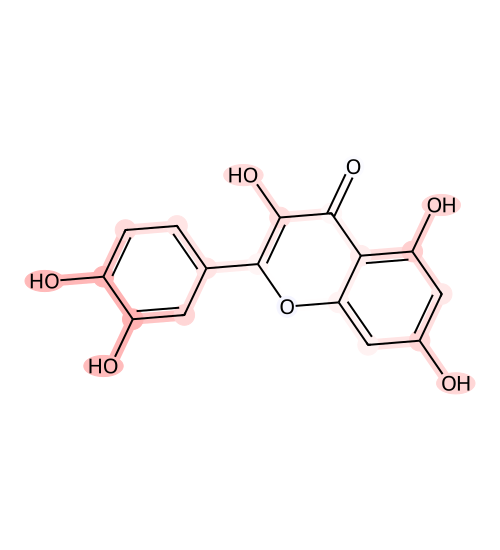

"<?xml version='1.0' encoding='iso-8859-1'?>\n<svg version='1.1' baseProfile='full'\n              xmlns='http://www.w3.org/2000/svg'\n                      xmlns:rdkit='http://www.rdkit.org/xml'\n                      xmlns:xlink='http://www.w3.org/1999/xlink'\n                  xml:space='preserve'\nwidth='500px' height='550px' viewBox='0 0 500 550'>\n<!-- END OF HEADER -->\n<rect style='opacity:1.0;fill:#FFFFFF;stroke:none' width='500.0' height='550.0' x='0.0' y='0.0'> </rect>\n<path class='bond-0 atom-0 atom-1' d='M 348.6,164.2 L 358.5,168.9 L 337.8,212.7 L 331.4,213.3 L 327.8,208.0 Z' style='fill:#FFFCFC;fill-rule:evenodd;fill-opacity:1;stroke:#FFFCFC;stroke-width:0.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-miterlimit:10;stroke-opacity:1;' />\n<path class='bond-1 atom-1 atom-2' d='M 327.8,208.0 L 331.4,213.3 L 328.7,219.0 L 283.6,222.7 L 280.0,217.5 L 282.7,211.7 Z' style='fill:#FFEAEA;fill-rule:evenodd;fill-opacity:1;stroke:#FFEAEA;stroke-width:0.0px;stroke-linecap:but

In [140]:
# ecfp

with open("result_SHAP/antioxidant_ecfp.pkl", "rb") as f:
    value = pickle.load(f)
visualize_shap_on_molecule("quercetin",
    df, 
    value, 
    radius = 3,
    nBits = 4096,
    compound_column = 'NAME',
    mol_column = 'ROMol',
    size = (500, 550)
)

!!!全分子に行う！！！

In [48]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.drawing.image import Image as OpenpyxlImage
from cairosvg import svg2png
from PIL import Image as PILImage
from io import BytesIO
from tqdm import tqdm

In [45]:
with open("result_SHAP/antioxidant_xor500000.pkl", "rb") as f:
    fpvalue = pickle.load(f)
with open("result_SHAP/antioxidant_ecfp.pkl", "rb") as f:
    ecfpvalue = pickle.load(f)
with open("data/10genre_all.pkl", "rb") as f:
    df = pickle.load(f)
df["NAME"] = [i[0] for i in list(df["compounds"])]

In [ ]:
categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin', 
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide'
    ]

for i in tqdm(categories):

    with open(f"result_SHAP/{i}_xor500000.pkl", "rb") as f:
        fpvalue = pickle.load(f)
    with open(f"result_SHAP/{i}_ecfp.pkl", "rb") as f:
        ecfpvalue = pickle.load(f)

    # Workbook作成
    wb = Workbook()
    ws = wb.active
    ws.title = f"{i}_SHAPVisualization"
    ws['A1'] = 'Compound Name'
    ws['B1'] = 'Fp Doc2vec'
    ws['C1'] = 'ECFP'
    ws.column_dimensions['A'].width = 20
    ws.column_dimensions['B'].width = 30
    ws.column_dimensions['C'].width = 30

    row = 2
    for compound_name in df["NAME"]:
        try:
            fpsvg = visualize_shap_on_molecule(
                compound_name, df, fpvalue, 3, 4096, 'NAME', 'ROMol', 
                "temp.svg")
            ecfpsvg = visualize_shap_on_molecule(
                compound_name, df, ecfpvalue, 3, 4096, 'NAME', 'ROMol', 
                "temp.svg")
            
            fppng_data = svg2png(bytestring=fpsvg.encode('utf-8'))
            ecfppng_data = svg2png(bytestring=ecfpsvg.encode('utf-8'))

            # PNGをExcelに埋め込み
            fpimg = OpenpyxlImage(BytesIO(fppng_data))
            fpimg.width = 200
            fpimg.height = 200
            ws.add_image(fpimg, f'B{row}')

            ecfpimg = OpenpyxlImage(BytesIO(ecfppng_data))
            ecfpimg.width = 200
            ecfpimg.height = 200
            ws.add_image(ecfpimg, f'C{row}')

            # 化合物名を記入
            ws[f'A{row}'] = compound_name
            ws.row_dimensions[row].height = 200
            
            # print(f"完了: {row-1}/{len(df['NAME'])} - {compound_name}")
            row += 1
            
        except Exception as e:
            ws[f'A{row}'] = compound_name
            ws[f'B{row}'] = f"Error: {e}"
            ws[f'C{row}'] = f"Error: {e}"
            print(f"エラー: {compound_name}")
            row += 1

    wb.save(f"result_SHAP/allcmp/{i}.xlsx")

In [47]:
with open("result_SHAP/antioxidant_xor500000.pkl", "rb") as f:
    fpvalue = pickle.load(f)
with open("result_SHAP/antioxidant_ecfp.pkl", "rb") as f:
    ecfpvalue = pickle.load(f)

# Workbook作成
wb = Workbook()
ws = wb.active
ws.title = "SHAP Visualization"

# ヘッダー
ws['A1'] = 'Compound Name'
ws['B1'] = 'Fp Doc2vec'
ws['C1'] = 'ECFP'

ws.column_dimensions['A'].width = 20
ws.column_dimensions['B'].width = 30
ws.column_dimensions['C'].width = 30

row = 2
for compound_name in df["NAME"]:
    try:
        # SVG生成
        fpsvg = visualize_shap_on_molecule(
            compound_name, df, fpvalue, 3, 4096, 'NAME', 'ROMol', 
            "temp.svg")
        ecfpsvg = visualize_shap_on_molecule(
            compound_name, df, ecfpvalue, 3, 4096, 'NAME', 'ROMol', 
            "temp.svg")
        
        # SVGをPNGに変換
        fppng_data = svg2png(bytestring=fpsvg.encode('utf-8'))
        ecfppng_data = svg2png(bytestring=ecfpsvg.encode('utf-8'))

        # PNGをExcelに埋め込み
        fpimg = OpenpyxlImage(BytesIO(fppng_data))
        fpimg.width = 200
        fpimg.height = 200
        ws.add_image(fpimg, f'B{row}')

        ecfpimg = OpenpyxlImage(BytesIO(ecfppng_data))
        ecfpimg.width = 200
        ecfpimg.height = 200
        ws.add_image(ecfpimg, f'C{row}')

        # 化合物名を記入
        ws[f'A{row}'] = compound_name
        ws.row_dimensions[row].height = 200
        
        print(f"完了: {row-1}/{len(df['NAME'])} - {compound_name}")
        row += 1
        
    except Exception as e:
        ws[f'A{row}'] = compound_name
        ws[f'B{row}'] = f"Error: {e}"
        ws[f'C{row}'] = f"Error: {e}"
        print(f"エラー: {compound_name}")
        row += 1

wb.save("result_SHAP/allcmp/抗酸化剤.xlsx")
print("完了！")

[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator


完了: 1/3926 - (-)-epicatechin
完了: 2/3926 - 2,6-dichlorobenzonitrile
完了: 3/3926 - aspartame
完了: 4/3926 - azlocillin
完了: 5/3926 - betulinic acid
完了: 6/3926 - calcein am


[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator


完了: 7/3926 - carbamazepine
完了: 8/3926 - cefaclor
完了: 9/3926 - cefdinir
完了: 10/3926 - cefoperazone
完了: 11/3926 - cefotetan
完了: 12/3926 - cefaloridine


[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:32] DEPRECATION WARNING: please use MorganGenerator
[13:11:33] DEPRECATION WARNING: please use MorganGenerator
[13:11:33] DEPRECATION WARNING: please use MorganGenerator
[13:11:33] DEPRECATION WARNING: please use MorganGenerator
[13:11:33] DEPRECATION WARNING: please use MorganGenerator
[13:11:33] DEPRECATION WARNING: please use MorganGenerator
[13:11:33] DEPRECATION WARNING: please use MorganGenerator


...

完了: 3921/3926 - Yo-Pro-3
完了: 3922/3926 - cefpirome
完了: 3923/3926 - corilagin


[13:13:50] DEPRECATION WARNING: please use MorganGenerator
[13:13:50] DEPRECATION WARNING: please use MorganGenerator
[13:13:50] DEPRECATION WARNING: please use MorganGenerator
[13:13:50] DEPRECATION WARNING: please use MorganGenerator
[13:13:50] DEPRECATION WARNING: please use MorganGenerator
[13:13:50] DEPRECATION WARNING: please use MorganGenerator


完了: 3924/3926 - gallamine
完了: 3925/3926 - mecarbam
完了: 3926/3926 - cefazolin


[13:13:50] DEPRECATION WARNING: please use MorganGenerator
[13:13:50] DEPRECATION WARNING: please use MorganGenerator
[13:13:50] DEPRECATION WARNING: please use MorganGenerator
[13:13:50] DEPRECATION WARNING: please use MorganGenerator


完了！


In [91]:
import matplotlib.pyplot as plt

In [114]:
def custom_violin_plot(shap_values, max_display=10, xlim=None, xlabel="SHAP value", ylabel_replace=('Feature', 'bit:'), ylim=None):
    shap.plots.violin(shap_values, max_display=max_display, show=False)
    
    ax = plt.gca()
    y_labels = ax.get_yticklabels()
    bit_numbers = []
    for label in y_labels:
        text = label.get_text()
        # "Feature X" から数字部分を抽出
        if ylabel_replace[0] in text:
            bit_num = int(text.replace(ylabel_replace[0], '').strip())
            bit_numbers.append(bit_num)

    # Y軸ラベル変更
    if ylabel_replace:
        y_labels = ax.get_yticklabels()
        new_labels = [label.get_text().replace(ylabel_replace[0], ylabel_replace[1]) for label in y_labels]
        ax.set_yticklabels(new_labels)
    
    # 軸ラベル設定
    if xlabel:
        plt.xlabel(xlabel)
    
    # 軸範囲設定
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    
    plt.show()
    return bit_numbers


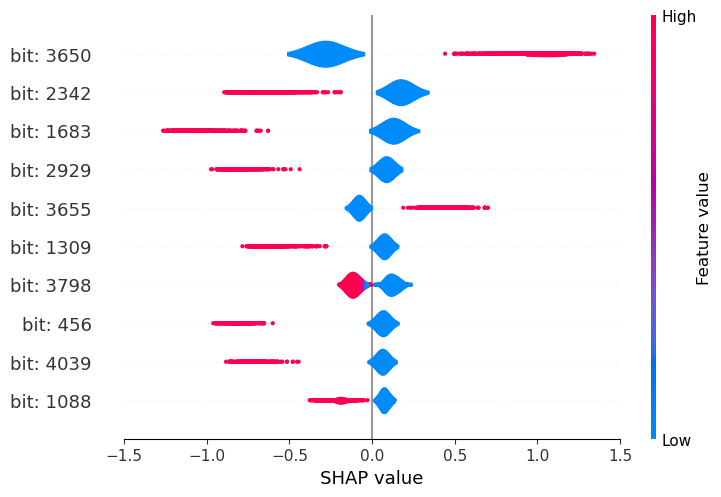

In [8]:
with open("result_SHAP/antioxidant_ecfp.pkl", "rb") as f:
    value = pickle.load(f)
custom_violin_plot(value, max_display=10, xlim=(-1.5, 1.5))

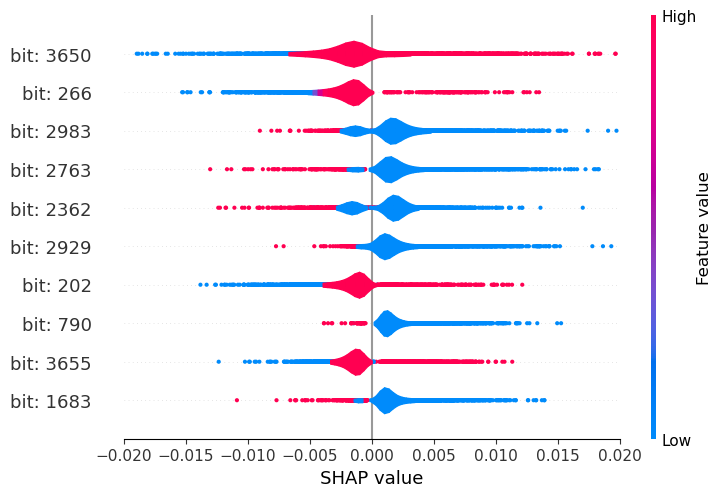

In [23]:
with open("result_SHAP/antioxidant_xor500000.pkl", "rb") as f:
    value = pickle.load(f)
custom_violin_plot(value, max_display=10, xlim=(-0.02, 0.02))

In [30]:
from rdkit.Chem import AllChem, Draw

In [ ]:
with open("data/10genre_all.pkl", "rb") as f:
    df = pickle.load(f)
finger_list = list(df["fp_3_4096"])
flag = False
for i in range(len(df)):
    for j in df.iat[i,21]:
        if j == 188:
            bitI_morgan = {}
            fp_morgan = AllChem.GetMorganFingerprintAsBitVect(df.iat[i,10], 3, nBits=4096, bitInfo=bitI_morgan)
            morgan_turples = ((df.iat[i,10] , bit, bitI_morgan) for bit in list(bitI_morgan.keys()))
            print(df.iat[i,0])
            flag = True
            break
    if flag:
        break

('(-)-epicatechin', 'Oc1cc(O)c2c(c1)O[C@H](c1ccc(O)c(O)c1)[C@H](O)C2', 'PFTAWBLQPZVEMU-UKRRQHHQSA-N')
{188: ((5, 2),), 231: ((20, 1),), 266: ((13, 3),), 315: ((13, 2),), 361: ((5, 1),), 416: ((8, 2),), 467: ((18, 3),), 589: ((15, 2),), 656: ((8, 0),), 750: ((8, 1),), 807: ((0, 0), (4, 0), (14, 0), (16, 0), (19, 0)), 858: ((10, 2),), 875: ((2, 1), (7, 1), (17, 1)), 1044: ((20, 3),), 1224: ((12, 3),), 1257: ((19, 1),), 1279: ((10, 1),), 1359: ((9, 3),), 1380: ((1, 0), (3, 0), (5, 0), (6, 0), (10, 0), (13, 0), (15, 0)), 1387: ((6, 2),), 1410: ((5, 3),), 1466: ((1, 3),), 1475: ((12, 2),), 1537: ((7, 2),), 1672: ((17, 2),), 1690: ((2, 3),), 1775: ((3, 2),), 1817: ((11, 3),), 1905: ((6, 1),), 2064: ((18, 2),), 2133: ((8, 3),), 2215: ((1, 2),), 2688: ((6, 3),), 2793: ((1, 1),), 2897: ((18, 1),), 2974: ((20, 0),), 3067: ((9, 0), (18, 0)), 3136: ((9, 1),), 3189: ((20, 2),), 3229: ((2, 2),), 3289: ((10, 3),), 3568: ((9, 2),), 3628: ((17, 3),), 3650: ((0, 1), (4, 1), (14, 1), (16, 1)), 3655: ((3,

[17:24:55] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
Draw.DrawMorganBits(morgan_turples, molsPerRow=4, legends=['bit: ' + str(x) for x in list(bitI_morgan.keys())], subImgSize=(300, 300))

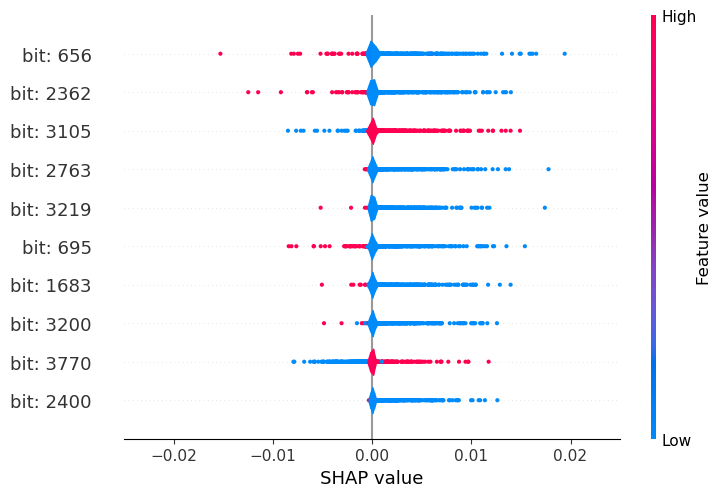

[656, 2362, 3105, 2763, 3219, 695, 1683, 3200, 3770, 2400]

In [145]:
with open("result_SHAP/fpdoc2vecvalue/volatile_oil_xor500000.pkl", "rb") as f:
    value = pickle.load(f)
li = custom_violin_plot(value, max_display=10, xlim=(-0.025, 0.025))
li.reverse()
li

In [143]:
from collections import Counter
target_bits = [656, 2362, 3105, 2763, 3219, 695, 1683, 3200, 3770, 2400]

with open("data/10genre_all.pkl", "rb") as f:
    df = pickle.load(f)

morgan_turples = []
for target_bit in target_bits:
    candidates = []
    
    # 全データセットから該当ビットを持つ分子を収集
    for i in range(len(df)):
        if target_bit in df.iat[i, 21]:
            bitI_morgan = {}
            mol = df.iat[i, 10]
            AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=4096, bitInfo=bitI_morgan)
            if target_bit in bitI_morgan:
                # 部分構造のタプルをソートしてハッシュ可能に
                candidates.append((mol, tuple(sorted(bitI_morgan[target_bit]))))
    
    if candidates:
        # 部分構造の出現回数をカウント
        structure_counts = Counter([c[1] for c in candidates])
        most_common_structure = structure_counts.most_common(1)[0][0]
        
        # 最頻出構造を持つ最初の分子を選択
        for mol, structure in candidates:
            if structure == most_common_structure:
                morgan_turples.append((mol, target_bit, {target_bit: list(most_common_structure)}))
                break

[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerator
[15:25:41] DEPRECATION WARNING: please use MorganGenerat

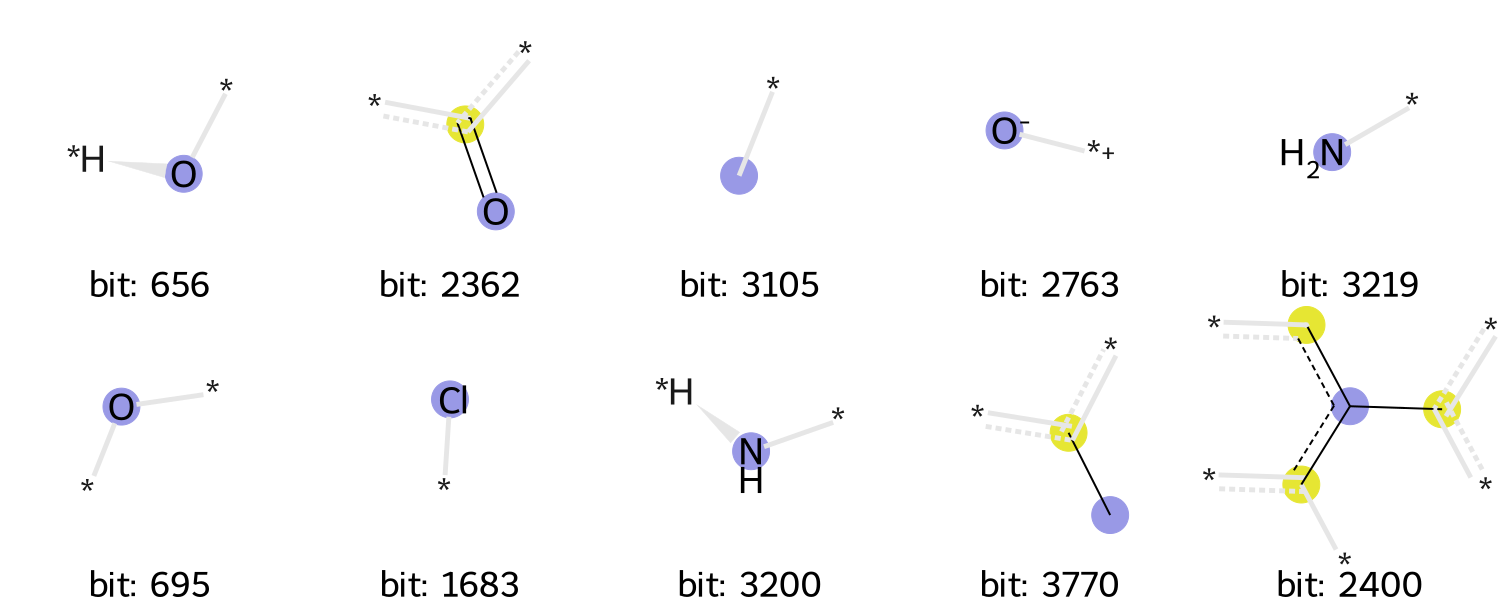

In [144]:
# drawOptionsでフォントサイズを設定
drawOptions = Draw.rdMolDraw2D.MolDrawOptions()
drawOptions.legendFontSize = 35
drawOptions.padding = 0.01

Draw.DrawMorganBits(
    morgan_turples, 
    molsPerRow=5, 
    legends=[f'bit: {t[1]}' for t in morgan_turples], 
    subImgSize=(300, 300),
    drawOptions=drawOptions
)